In [1]:
# pip install tensorflow

In [13]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.layers import SpatialDropout1D
import joblib

In [14]:
# Load cleaned dataset
df = pd.read_csv("data_cleaned.csv")
df

,title,text,subject,date,real
0,Donald Trump Sends Out Embarrassing New Yearâ...,Donald Trump just couldn t wish all Americans ...,News,12/31/2017,0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,12/31/2017,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,12/30/2017,0
3,Trump Is So Obsessed He Even Has Obamaâ€™s Na...,"On Christmas day, Donald Trump announced that ...",News,12/29/2017,0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,12/25/2017,0
...,...,...,...,...,...
38623,North Korea shipments to Syria chemical arms a...,UNITED NATIONS (Reuters) - Two North Korean sh...,worldnews,8/21/2017,1
38624,Fully committed NATO backs new U.S. approach o...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,8/22/2017,1
38625,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,8/22/2017,1
38626,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,8/22/2017,1


In [15]:
# Define features (statements) and labels
texts = df["text"].astype(str).values  # Ensure text data is string
y = df["real"].values

# Tokenization & Sequence Padding
max_words = 10000  # Vocabulary size
max_len = 100  # Max sequence length

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post')

# Manually shuffle before training to ensure adequate shuffling of the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, y, test_size=0.2, random_state=42, stratify=y)

# Check the most frequent words in the dataset and see if any are explicit markers of truth/falsity
word_counts = pd.Series(tokenizer.word_counts).sort_values(ascending=False)
print(word_counts.head(20))  # Check top 20 most common words

the      862993
to       458618
of       372567
a        353731
and      345710
in       301834
that     202646
s        189453
on       168525
for      147656
is       140145
said     122491
he       116116
trump    109971
it       109331
with     100590
was       96391
as        88386
his       84111
by        81175
dtype: int64


In [16]:
# Build Optimized LSTM-GRU Model
model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(128, return_sequences=True, recurrent_dropout=0.3)),
    Bidirectional(GRU(64, recurrent_dropout=0.3)),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile Model
model.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), metrics=['accuracy'])

# Train Model
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test), callbacks=[early_stopping])


Epoch 1/10


C:\Users\agmil\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


483/483 ━━━━━━━━━━━━━━━━━━━━ 156s 305ms/step - accuracy: 0.8566 - loss: 0.3139 - val_accuracy: 0.9821 - val_loss: 0.0547
Epoch 2/10
483/483 ━━━━━━━━━━━━━━━━━━━━ 130s 269ms/step - accuracy: 0.9881 - loss: 0.0440 - val_accuracy: 0.9808 - val_loss: 0.0523
Epoch 3/10
483/483 ━━━━━━━━━━━━━━━━━━━━ 136s 282ms/step - accuracy: 0.9941 - loss: 0.0238 - val_accuracy: 0.9850 - val_loss: 0.0557
Epoch 4/10
483/483 ━━━━━━━━━━━━━━━━━━━━ 137s 284ms/step - accuracy: 0.9967 - loss: 0.0134 - val_accuracy: 0.9817 - val_loss: 0.0878
Epoch 5/10
483/483 ━━━━━━━━━━━━━━━━━━━━ 136s 281ms/step - accuracy: 0.9970 - loss: 0.0098 - val_accuracy: 0.9846 - val_loss: 0.0901


In [17]:
# Evaluate Model
y_pred = (model.predict(X_test) > 0.5).astype("int32")
accuracy = accuracy_score(y_test, y_pred)
print(f"LSTM-GRU Model Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

242/242 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step
LSTM-GRU Model Accuracy: 0.9808
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3488
           1       0.98      0.98      0.98      4238

    accuracy                           0.98      7726
   macro avg       0.98      0.98      0.98      7726
weighted avg       0.98      0.98      0.98      7726



In [18]:
# pip install shap

PermutationExplainer explainer: 101it [41:46, 25.07s/it]                                                               
C:\Users\agmil\AppData\Local\Temp\ipykernel_4072\3905070363.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test[:100])


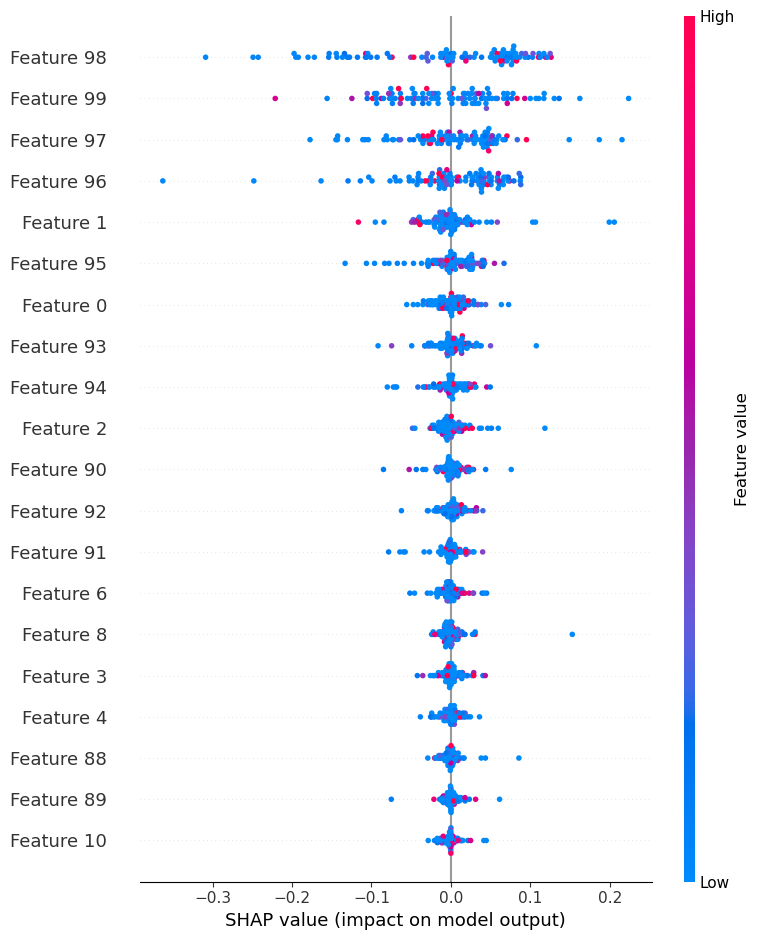

In [19]:
import shap

# Explain model predictions using SHAP
explainer = shap.Explainer(model, X_test[:100])  # Using a subset for efficiency
shap_values = explainer(X_test[:100])

# SHAP Summary Plot (feature importance visualization)
shap.summary_plot(shap_values, X_test[:100])


In [20]:
word_index = tokenizer.word_index
index_word = {v: k for k, v in word_index.items()}  # Reverse mapping

# Print the most important words based on SHAP importance
important_token_indices = np.argsort(np.abs(shap_values.values).mean(axis=0))[-20:]
important_words = [index_word.get(idx, "<UNK>") for idx in important_token_indices]

print(f"Top important words: {important_words}")

Top important words: ['on', 'white', 'obama', 'of', 'to', 'that', 'and', 'campaign', 'two', 'into', 'the', 'against', 'do', '<UNK>', 'like', '<OOV>', 'election', 'because', 'last', 'them']


In [21]:
# Save Model & Tokenizer
model.save("fake_news_lstm_model.h5")
joblib.dump(tokenizer, "tokenizer.pkl")
print("LSTM-GRU model and tokenizer saved!")

LSTM-GRU model and tokenizer saved!


In [22]:
# Load the tokenizer
tokenizer = joblib.load("tokenizer.pkl")  # Ensure the correct path

# Retrieve the word index from the tokenizer
word_index = tokenizer.word_index
index_word = {v: k for k, v in word_index.items()}  # Reverse mapping

# Replace this with actual SHAP values ranking if available
important_token_indices = list(range(87, 100))  # Example based on SHAP summary plot

# Map token indices back to actual words
important_words = [index_word.get(idx, "<UNK>") for idx in important_token_indices]

print(f"Top important words: {important_words}")


Top important words: ['told', 'obama', 'white', 'into', 'campaign', 'two', 'do', 'against', 'like', 'election', 'because', 'them', 'last']


In [24]:
# Inspect Word Frequencies Across Classes:
for word in ['told', 'obama', 'white', 'into', 'campaign', 'two', 'do', 'against', 'like', 'election', 'because', 'them', 'last']:
    print(f"'{word}' appears {df[df['real'] == 1]['text'].str.contains(word, case=False).sum()} times in REAL news")
    print(f"'{word}' appears {df[df['real'] == 0]['text'].str.contains(word, case=False).sum()} times in FAKE news")


'told' appears 9146 times in REAL news
'told' appears 4408 times in FAKE news
'obama' appears 4119 times in REAL news
'obama' appears 4801 times in FAKE news
'white' appears 4802 times in REAL news
'white' appears 4790 times in FAKE news
'into' appears 7843 times in REAL news
'into' appears 8680 times in FAKE news
'campaign' appears 5322 times in REAL news
'campaign' appears 4378 times in FAKE news
'two' appears 8313 times in REAL news
'two' appears 5135 times in FAKE news
'do' appears 17457 times in REAL news
'do' appears 15759 times in FAKE news
'against' appears 6704 times in REAL news
'against' appears 4939 times in FAKE news
'like' appears 5858 times in REAL news
'like' appears 9431 times in FAKE news
'election' appears 6258 times in REAL news
'election' appears 3726 times in FAKE news
'because' appears 4537 times in REAL news
'because' appears 7239 times in FAKE news
'them' appears 5515 times in REAL news
'them' appears 7374 times in FAKE news
'last' appears 8605 times in REAL ne

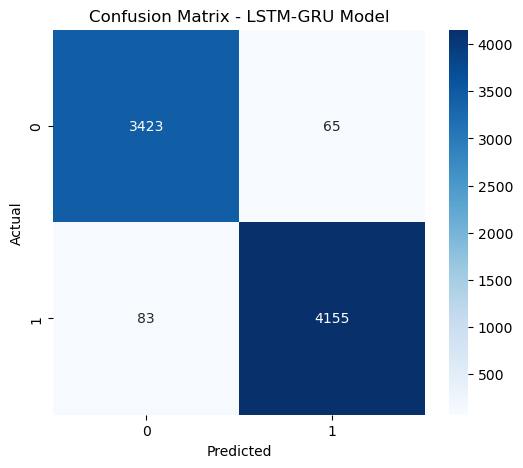

In [25]:
# Confusion Matrix Visualization
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - LSTM-GRU Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()